# 02 -- Vectors and vector spaces

| question | answer |
|---|---|
| What physics problem? | Forces and fields have magnitude and direction. |
| What mathematics? | Vector spaces, inner product, cross product, projection, orthonormal bases. |
| What algorithm? | Dot and cross products; modified Gram-Schmidt orthonormalization. |
| What software? | NumPy arrays; physkit.linalg.gram_schmidt; SymPy matrices. |
| What experiment? | A force sensor reports three orthogonal components. |
| What engineering application? | A vector is a contiguous array; SIMD lanes process its components. |

This notebook follows the repository template: English explanation, mathematical derivation,
dimensions and SI units, SymPy derivation, NumPy implementation, Pandas tables, Matplotlib plots,
optional PyTorch, exercises, and engineering applications. It reuses the `physkit` package and the
results of earlier chapters.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## English explanation

A vector carries a magnitude and a direction. Physical vectors -- force, velocity, electric
field -- add tip-to-tail and scale by real numbers, which is exactly the definition of a vector
space. Two operations extract geometry from components: the **inner (dot) product** gives lengths and
angles, and the **cross product** gives the perpendicular and the area of the spanned parallelogram.
Orthonormal bases let any vector be written as independent coordinates.

Subject-verb-object: the field points somewhere; the dot product measures alignment; the basis names
the coordinates.

## Mathematical derivation

For $\mathbf a,\mathbf b\in\mathbb R^3$, the dot product $\mathbf a\cdot\mathbf
b=\sum_i a_i b_i=|\mathbf a||\mathbf b|\cos\theta$ and the cross product magnitude
$|\mathbf a\times\mathbf b|=|\mathbf a||\mathbf b|\sin\theta$. Squaring and adding gives the
**Lagrange identity** $(\mathbf a\cdot\mathbf b)^2+|\mathbf a\times\mathbf b|^2=|\mathbf
a|^2|\mathbf b|^2$. The projection of $\mathbf a$ onto $\mathbf b$ is
$\mathrm{proj}_{\mathbf b}\mathbf a=\frac{\mathbf a\cdot\mathbf b}{\mathbf b\cdot\mathbf
b}\mathbf b$, the building block of Gram-Schmidt.

## Dimensions and SI units

Every component of a force vector is a force (newtons), and so is its magnitude. The dot product
of two forces would carry units of $\mathrm{N}^2$; a projection stays in newtons. `physkit.units`
confirms a component is a force and that the magnitude keeps that dimension.

In [2]:
Fx = U.Quantity(3.0, U.FORCE); Fy = U.Quantity(4.0, U.FORCE)
mag = (Fx*Fx + Fy*Fy) ** 0.5          # sqrt(Fx^2 + Fy^2)
print("force component dim:", Fx.dim, "| magnitude dim:", mag.dim, "| |F| =", mag.value, "N")
assert mag.dim == U.FORCE

force component dim: L^1 M^1 T^-2 | magnitude dim: L^1 M^1 T^-2 | |F| = 5.0 N


## SymPy derivation

SymPy verifies the Lagrange identity symbolically for general components.

In [3]:
a = sp.Matrix(sp.symbols('a1 a2 a3'))
b = sp.Matrix(sp.symbols('b1 b2 b3'))
dot = (a.T*b)[0]
cross = a.cross(b)
lhs = dot**2 + (cross.T*cross)[0]
rhs = (a.T*a)[0] * (b.T*b)[0]
assert sp.simplify(lhs - rhs) == 0
print("Lagrange identity (a.b)^2 + |axb|^2 = |a|^2 |b|^2 verified symbolically")

Lagrange identity (a.b)^2 + |axb|^2 = |a|^2 |b|^2 verified symbolically


## NumPy implementation

In [4]:
a = np.array([3.0, 4.0, 0.0]); b = np.array([1.0, 0.0, 0.0])
dot = float(a @ b)
angle = np.degrees(np.arccos(dot / (np.linalg.norm(a)*np.linalg.norm(b))))
proj = (dot / (b @ b)) * b
print(f"a.b = {dot} | |a| = {np.linalg.norm(a)} | angle(a,b) = {angle:.1f} deg")
print(f"projection of a onto b = {proj}")

# orthonormal basis from three random vectors (reuse physkit.linalg)
rng = np.random.default_rng(0)
Q = la.gram_schmidt(rng.standard_normal((3, 3)))
print("Gram-Schmidt basis orthonormal:", np.allclose(Q.conj().T @ Q, np.eye(3)))

a.b = 3.0 | |a| = 5.0 | angle(a,b) = 53.1 deg
projection of a onto b = [3. 0. 0.]
Gram-Schmidt basis orthonormal: True


## Pandas tables

In [5]:
vs = {"e_x": [1,0,0], "e_y": [0,1,0], "a": [3,4,0], "d": [1,1,1.0]}
rows = []
for name, v in vs.items():
    v = np.array(v, float)
    rows.append({"vector": name, "norm": round(np.linalg.norm(v), 4),
                 "angle_to_x_deg": round(np.degrees(np.arccos(v[0]/np.linalg.norm(v))), 1)})
print(pd.DataFrame(rows).to_string(index=False))

vector   norm  angle_to_x_deg
   e_x 1.0000             0.0
   e_y 1.0000            90.0
     a 5.0000            53.1
     d 1.7321            54.7


## Matplotlib plots

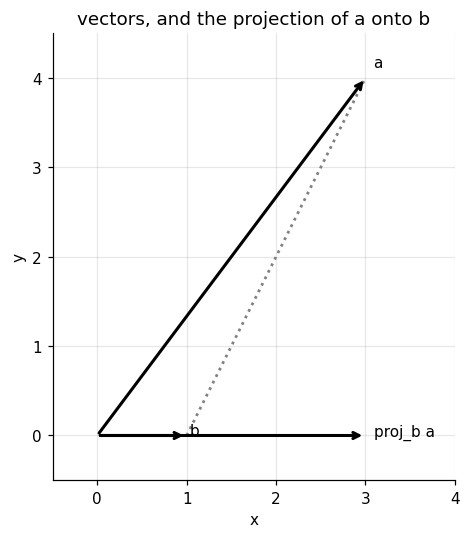

In [6]:
fig, ax = plt.subplots(figsize=(5.2, 5))
for v, lab in [(a, "a"), (b, "b"), (proj, "proj_b a")]:
    ax.annotate("", xy=(v[0], v[1]), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", lw=2))
    ax.text(v[0]*1.03, v[1]*1.03, lab)
ax.plot([b[0], a[0]], [b[1], a[1]], ":", color="gray")
ax.set_xlim(-0.5, 4); ax.set_ylim(-0.5, 4.5); ax.set_aspect("equal")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("vectors, and the projection of a onto b")
plt.tight_layout(); plt.show()

## PyTorch (optional)

In [7]:
if torch is not None:
    at, bt = torch.tensor(a), torch.tensor(b)
    print("torch dot:", float(at @ bt), "| torch cross:", torch.linalg.cross(at, bt).tolist())
else:
    print("PyTorch absent -- NumPy dot/cross above are authoritative.")

PyTorch absent -- NumPy dot/cross above are authoritative.


## Exercises

1. Verify numerically that the cross product is anti-commutative, $\mathbf a\times\mathbf
   b=-\mathbf b\times\mathbf a$, and that $\mathbf a\cdot(\mathbf a\times\mathbf b)=0$.
2. Given a plane's normal $\mathbf n$, decompose a vector into components parallel and perpendicular
   to the plane using projection.
3. Show that Gram-Schmidt applied to a linearly dependent set raises; explain the geometric meaning.

## Engineering applications

A three-axis **sensor** delivers a force or field as three numbers; **firmware** stores them as
a contiguous array, and a **SIMD** unit computes the dot product across lanes in one instruction.
Orthonormal bases underlie coordinate transforms in **DSP** and the change-of-basis a **GPU** applies
to render or rotate data. The vector abstraction is the same in the physics and in the memory layout.

Summary (subject-verb-object): the sensor reports components; the dot product measures alignment;
Gram-Schmidt builds the basis; the array stores the vector.